In [15]:
# Esto es solo para poder debugear.
# !pip install -q ipdb

import torch
import numpy as np
import sys
import time
# import ipdb
from ucimlrepo import fetch_ucirepo 
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

# Genera una semilla fija para que los experimentos sea repetibles.
# t_cg = torch.manual_seed(1547)

In [16]:
# Dataset 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 


                  name     role         type demographic description units  \
0                   ID       ID  Categorical        None        None  None   
1            Diagnosis   Target  Categorical        None        None  None   
2              radius1  Feature   Continuous        None        None  None   
3             texture1  Feature   Continuous        None        None  None   
4           perimeter1  Feature   Continuous        None        None  None   
5                area1  Feature   Continuous        None        None  None   
6          smoothness1  Feature   Continuous        None        None  None   
7         compactness1  Feature   Continuous        None        None  None   
8           concavity1  Feature   Continuous        None        None  None   
9      concave_points1  Feature   Continuous        None        None  None   
10           symmetry1  Feature   Continuous        None        None  None   
11  fractal_dimension1  Feature   Continuous        None        

In [17]:
class UciDataset(Dataset):
  def __init__(self, X_df, y_df):
    
    # 1. Convertir DataFrames a numpy
    X_numpy = X_df.values
    Y_numpy = y_df.values.ravel()
    
    # 2. Pre-procesar Y (target)
    le = LabelEncoder()
    Y_numpy = le.fit_transform(Y_numpy)
    
    # 3. Pre-procesar X (features)
    scaler = StandardScaler()
    X_numpy_scaled = scaler.fit_transform(X_numpy)
    
    # 4. Convertir a Tensores 
    self.X = torch.tensor(X_numpy_scaled, dtype=torch.float32)
    self.Y = torch.tensor(Y_numpy, dtype=torch.float32).unsqueeze(1) # BCELoss lo quiere con shape [N, 1]
    
    self.num_features = self.X.shape[1] # Esto será 30

  # Retorna el tamaño total del dataset
  def __len__(self):
    return len(self.X)

  # Retorna un solo ejemplo (X, Y)
  def __getitem__(self, i):
    return self.X[i], self.Y[i]

In [18]:
# 1. Dataset
dataset = UciDataset(X, y)

# 2. Features
d0 = dataset.num_features 
print(f"El dataset tiene {d0} features.")

# 3. Entrenamiento y validación (80% train, 20% val)
total_size = len(dataset)
train_size = int(total_size * 0.7)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Datos divididos: {len(train_dataset)} para entrenar, {len(val_dataset)} para validar.")

# 4. Crear los DataLoaders
batch_size = 32 # Un buen punto de partida
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

El dataset tiene 30 features.
Datos divididos: 398 para entrenar, 171 para validar.


In [19]:
# GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando dispositivo: {device}")

def loop_FFNN(modelo, train_loader, val_loader, optimizador, perdida_func, epochs, reports_every=1):
    
    # Listas para guardar las métricas de cada época
    hist_train_loss = []
    hist_val_loss = []
    hist_val_acc = []
    
    # Comienza el entrenamiento
    tiempo_total = time.perf_counter()
    
    for e in range(1, epochs + 1):
        inicio_epoch = time.perf_counter()
        
        # --- BUCLE DE ENTRENAMIENTO ---
        modelo.train() # Pone el modelo en modo de entrenamiento (activa Dropout, etc.)
        loss_epoch_train = 0.0 # Acumulador para la pérdida de entrenamiento de esta época
        
        for (x_batch, y_batch) in train_loader:
            # Mueve los datos del lote al dispositivo (GPU/CPU)
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            # 1. Pasada hacia adelante (Predicción)
            y_pred = modelo.forward(x_batch)
            
            # 2. Calcular el Error (Loss)
            L = perdida_func(y_pred, y_batch)
            
            # 3. Backpropagation (Calcular gradientes)
            L.backward()
            
            # 4. Actualizar Pesos (Descenso de gradiente)
            optimizador.step()
            
            # 5. Limpiar Gradientes
            optimizador.zero_grad()
            
            # Acumula la pérdida del lote
            loss_epoch_train += L.item()
            
        # Guarda la pérdida de entrenamiento promedio de esta época
        avg_train_loss = loss_epoch_train / len(train_loader)
        hist_train_loss.append(avg_train_loss)
        
        # --- BUCLE DE VALIDACIÓN ---
        if e % reports_every == 0:
            modelo.eval() # Pone el modelo en modo evaluación (desactiva Dropout, etc.)
            
            total_correctos_val = 0
            loss_epoch_val = 0.0
            
            # Desactiva el cálculo de gradientes para ahorrar memoria
            with torch.no_grad():
                for (x_val, y_val) in val_loader:
                    x_val, y_val = x_val.to(device), y_val.to(device)
                    
                    # 1. Predicción de validación
                    y_pred_val = modelo.forward(x_val)
                    
                    # 2. Calcular pérdida de validación
                    L_val = perdida_func(y_pred_val, y_val)
                    loss_epoch_val += L_val.item()
                    
                    # 3. Calcular precisión de validación
                    y_pred_bin = (y_pred_val >= 0.5).float()
                    correctos = torch.sum(y_pred_bin == y_val).item()
                    total_correctos_val += correctos
            
            # Calcula las métricas promedio de validación
            avg_val_loss = loss_epoch_val / len(val_loader)
            avg_val_acc = (total_correctos_val / len(val_loader.dataset)) * 100
            
            hist_val_loss.append(avg_val_loss)
            hist_val_acc.append(avg_val_acc)
            
            tiempo_epoch_actual = time.perf_counter() - inicio_epoch
            
            # Imprime el reporte
            sys.stdout.write(
                  f'\rEpoch:{e:03d} | Train Loss:{avg_train_loss:.4f}'
                + f' | Val Loss:{avg_val_loss:.4f} | Val Acc:{avg_val_acc:.2f}%'
                + f' | Tiempo:{tiempo_epoch_actual:.2f}s'
            )
        
    tiempo_total_fin = time.perf_counter() - tiempo_total
    print(f"\nEntrenamiento finalizado en {tiempo_total_fin:.2f} segundos.")
    
    return hist_train_loss, hist_val_loss, hist_val_acc

Usando dispositivo: cuda


In [20]:
class FFNN(torch.nn.Module):
  def __init__(self, d0, d1, d2, dropout_prob=0.5):
    """
    Constructor de la Red Neuronal.
    Define las capas que se usarán.
    
    Parámetros:
    d0 (int): Dimension de entrada (número de features)
    d1 (int): Número de neuronas en la primera capa oculta
    d2 (int): Número de neuronas en la segunda capa oculta
    dropout_prob (float): Probabilidad de Dropout (ej. 0.5)
    """
    super(FFNN, self).__init__()
    
    # Definimos capas (automáticamente se registran como parametros)
    self.fc1 = torch.nn.Linear(d0, d1, bias=True)
    self.fc2 = torch.nn.Linear(d1, d2, bias=True)
    self.fc3 = torch.nn.Linear(d2,  1, bias=True)
    
    # Capas de Dropout para regularización
    self.dropout1 = torch.nn.Dropout(dropout_prob)
    self.dropout2 = torch.nn.Dropout(dropout_prob)
          
  # Computa la pasada hacia adelante
  def forward(self, x):
    """
    Define el flujo de los datos a través de la red.
    """
    # Capa 1: Lineal -> ReLU -> Dropout
    u1 = self.fc1(x)
    h1 = torch.tanh(u1) # Usamos ReLU en lugar de tanh
    h1_drop = self.dropout1(h1)
    
    # Capa 2: Lineal -> ReLU -> Dropout
    u2 = self.fc2(h1_drop)
    h2 = torch.sigmoid(u2) # Usamos ReLU en lugar de sigmoid
    h2_drop = self.dropout2(h2)
    
    # Capa 3: Salida (Lineal -> Sigmoid)
    u3 = self.fc3(h2_drop)
    y_pred = torch.sigmoid(u3) # Sigmoid es correcto para la salida binaria
      
    return y_pred

Epoch:050 | Train Loss:0.0513 | Val Loss:0.0930 | Val Acc:97.66% | Tiempo:0.02s
Entrenamiento finalizado en 0.98 segundos.
Graficando métricas...


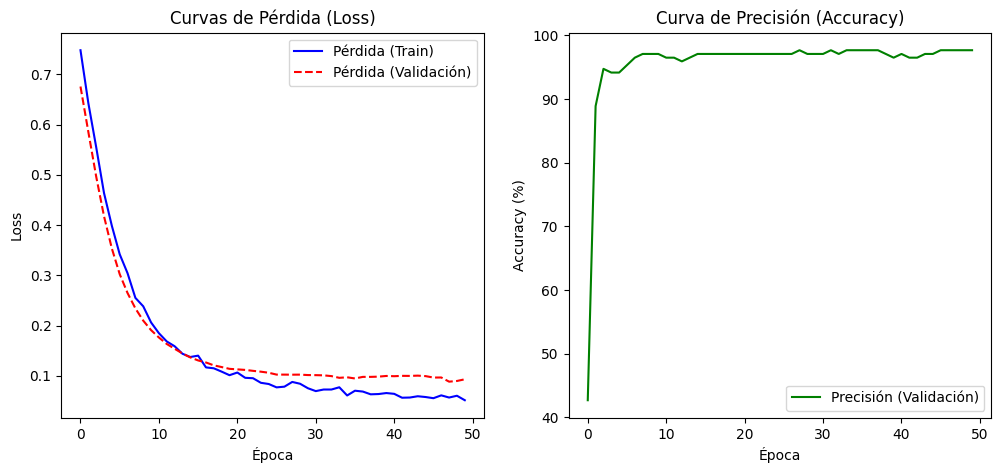

In [26]:
# --- PREPARACIÓN DEL MODELO ---
d0 = dataset.num_features 
d1 = 64  
d2 = 32  

red = FFNN(d0, d1, d2) 
red.to(device) # Mueve la red al dispositivo (GPU/CPU)

# --- PREPARACIÓN DE ENTRENAMIENTO ---
epochs = 50
learning_rate = 0.001 # Un buen lr para Adam

# Optimizador Adam (¡mucho mejor que SGD!)
optimizador = torch.optim.Adam(red.parameters(), lr=learning_rate)

# Función de pérdida (Binary Cross-Entropy)
perdida = torch.nn.BCELoss()

# --- EJECUTAR ENTRENAMIENTO ---
metricas = loop_FFNN(red, train_loader, val_loader, optimizador, perdida, epochs)

hist_train_loss, hist_val_loss, hist_val_acc = metricas

# --- GRAFICAR RESULTADOS ---
print("Graficando métricas...")

plt.figure(figsize=(12, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(hist_train_loss, label='Pérdida (Train)', color='blue')
plt.plot(hist_val_loss, label='Pérdida (Validación)', color='red', linestyle='--')
plt.title("Curvas de Pérdida (Loss)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(hist_val_acc, label='Precisión (Validación)', color='green')
plt.title("Curva de Precisión (Accuracy)")
plt.xlabel("Época")
plt.ylabel("Accuracy (%)")
plt.legend()
